In [1]:
import eos
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
from IPython.display import display, Latex
#import re
import yaml
#from tabulate import tabulate
from wquantiles import quantile
from collections import OrderedDict
from scipy import integrate
import mpmath as mp
import sympy as sp

import chi_OPE as chi

BASE_DIRECTORY='./data_base'
TEST_BASE_DIRECTORY='./test_base'
ANALYSIS_FILE='./an_file.yaml'

def weighted_mean_std(samples, weights):
    mean = np.average(samples, weights=weights)
    var = np.average((samples - mean) ** 2, weights=weights)
    return mean, np.sqrt(var)

def find_index_for_q2(prediction, obs_name, q2_value):
    candidates = []
    for idx, item in enumerate(prediction.varied_parameters):
        if item.get('name') != obs_name:
            continue
        kin = item.get('kinematics', {})
        if 'q2' in kin:
            candidates.append((idx, float(kin['q2'])))
    if not candidates:
        return None, None
    idx, q2_best = min(candidates, key=lambda t: abs(t[1] - q2_value))
    return idx, q2_best

def range_from_pred(prediction, obs_name, q2_vals, nsigma=3.0, pad_frac=0.1):
    vals = []
    for q2 in q2_vals:
        idx, _ = find_index_for_q2(prediction, obs_name, q2)
        if idx is None:
            continue
        mean, std = weighted_mean_std(prediction.samples[:, idx], prediction.weights)
        vals.extend([mean - nsigma * std, mean + nsigma * std])
    if not vals:
        return [0.0, 1.0]
    vmin, vmax = min(vals), max(vals)
    pad = (vmax - vmin) * pad_frac if vmax != vmin else max(abs(vmin) * pad_frac, 1e-4)
    return [vmin - pad, vmax + pad]

def print_params_from_posterior(base, posterior):
    posterior_dir = os.path.join(base, 'data', posterior, 'samples')

    data = eos.data.ImportanceSamples(posterior_dir)
    samples = data.samples
    weights = data.weights
    varied = [p["name"] for p in data.varied_parameters]
    for name in varied:
        idx = varied.index(name)
        mean, std = weighted_mean_std(samples[:, idx], weights)
        print(f"{name}: {mean:e} ± {std:.2e}")

def print_pred_from_posterior(base, posterior, pred_name, obs_name, q2_vals):
    pred_dir = os.path.join(base, 'data', posterior, f'pred-{pred_name}')
    data = eos.data.Prediction(pred_dir)
    samples = data.samples
    weights = data.weights

    idx_q2best = []
    for q2 in q2_vals:
        idx, q2_best = find_index_for_q2(data, obs_name, q2)
        if idx is not None:
            idx_q2best.append((idx, q2_best))
    if not idx_q2best:
        print(f"No entries found for {obs_name} in {pred_name}")
        return
    for idx, q2_best in idx_q2best:
        mean, std = weighted_mean_std(samples[:, idx], weights)
        print(f"{obs_name} at q^2={q2_best:.1f}: {mean:e} ± {std:.2e}")

Use the res function? (y/n)


Inserting custom observables ...
Inserted observable: b->s::Re{Delta_C7_Qc}(-7)


Including the resonance factor in the integrand.


Inserted observable: b->s::Im{Delta_C7_Qc}(-7)
Inserted observable: b->s::Re{Delta_C9_Qc}(-7)
Inserted observable: b->s::Im{Delta_C9_Qc}(-7)
Inserted observable: b->s::Re{Delta_C7_Qc}(-5)
Inserted observable: b->s::Im{Delta_C7_Qc}(-5)
Inserted observable: b->s::Re{Delta_C9_Qc}(-5)
Inserted observable: b->s::Im{Delta_C9_Qc}(-5)
Inserted observable: b->s::Re{Delta_C7_Qc}(-3)
Inserted observable: b->s::Im{Delta_C7_Qc}(-3)
Inserted observable: b->s::Re{Delta_C9_Qc}(-3)
Inserted observable: b->s::Im{Delta_C9_Qc}(-3)
Inserted observable: b->s::Re{Delta_C7_Qc}(-1)
Inserted observable: b->s::Im{Delta_C7_Qc}(-1)
Inserted observable: b->s::Re{Delta_C9_Qc}(-1)
Inserted observable: b->s::Im{Delta_C9_Qc}(-1)
Inserted observable: B->K::Re{H_0(-7,F)}
Inserted observable: B->K::Im{H_0(-7,F)}
Inserted observable: B->K::Re{H_0(-5,F)}
Inserted observable: B->K::Im{H_0(-5,F)}
Inserted observable: B->K::Re{H_0(-3,F)}
Inserted observable: B->K::Im{H_0(-3,F)}
Inserted observable: B->K::Re{H_0(-1,F)}
Inserted

Accordion(children=(Output(layout=Layout(height='200px', overflow='auto')),), titles=('data/BSZ-BqToK-wSR-wNFF…

parameter,value
"$\alpha_{+,0}^{B \to K,\mathrm{BSZ2015}}$",0.3386
"$\alpha_{+,1}^{B \to K,\mathrm{BSZ2015}}$",-0.8678
"$\alpha_{+,2}^{B \to K,\mathrm{BSZ2015}}$",-0.0639
"$\alpha_{0,1}^{B \to K,\mathrm{BSZ2015}}$",0.3804
"$\alpha_{0,2}^{B \to K,\mathrm{BSZ2015}}$",0.0908
"$\alpha_{T,0}^{B \to K,\mathrm{BSZ2015}}$",0.3232
"$\alpha_{T,1}^{B \to K,\mathrm{BSZ2015}}$",-0.9742
"$\alpha_{T,2}^{B \to K,\mathrm{BSZ2015}}$",-0.2791
"$\mathrm{Re}\, \hat{\mathcal{H}}_+^{B\to Kc\bar{c}}(m7)$",0.0000
"$\mathrm{Im}\, \hat{\mathcal{H}}_+^{B\to Kc\bar{c}}(m7)$",-0.0000


Delta chi_V (Q2 = 1.747e+01) = 2.3266e-08
2.2951e-08 + 3.0459e-10 = 2.3256e-08


$\chi_{OPE}$ is implemented in the imported ```chi_OPE.py```.
Args: subtraction point, s0 

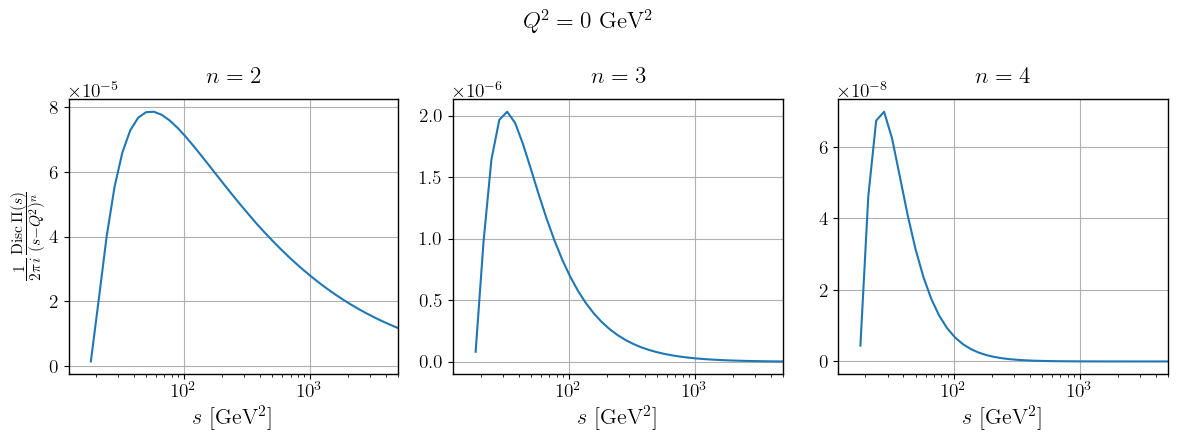

In [6]:
#Q2 = chi.mb**2
Q2 = 0
s_min = (chi.mb + chi.ms)**2

xmax = 5000
xmin = s_min / 1.5

#s_vals = np.linspace(s_min, xmax, 10)
s_vals = np.geomspace(s_min, xmax, 40)

n_subtractions_plus_1 = [2, 3, 4]

fig, axes = plt.subplots(1, len(n_subtractions_plus_1), figsize=(4 * len(n_subtractions_plus_1), 4.5), sharex=True)

if len(n_subtractions_plus_1) == 1:
    axes = [axes]

for ax, n in zip(axes, n_subtractions_plus_1):
    f_vals = np.array([chi.to_integrate(s, Q2, n_subtractions_plus_1=n, with_res_factor=False) for s in s_vals])
    ax.semilogx(s_vals, f_vals)
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel(R'$s$ [GeV$^2$]')
    ax.set_title(fR'$n={n}$')
    ax.grid(True)

axes[0].set_ylabel(R'$\frac{1}{2\pi i}\frac{\mathrm{Disc}\,\Pi(s)}{(s-Q^2)^n}$')
fig.suptitle(fR'$Q^2={Q2}$ GeV$^2$')
fig.tight_layout()
fig.savefig("without_res_factor", format="pdf", bbox_inches="tight")
plt.show()

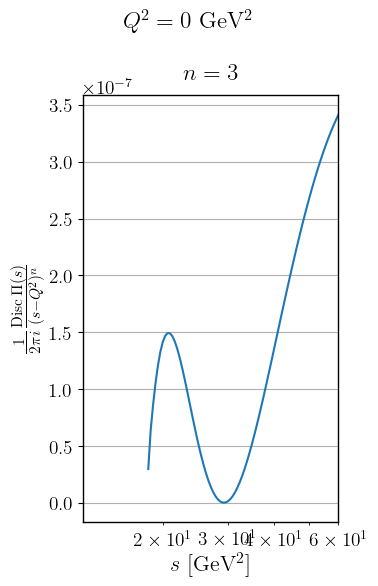

In [9]:
#Q2 = chi.mb**2
Q2 = 0
s_min = (chi.mb + chi.ms)**2

xmax = 60
xmin = s_min / 1.5

#s_vals = np.linspace(s_min, xmax, 10)
s_vals = np.geomspace(s_min, xmax, 80)

n_subtractions_plus_1 = [3]

fig, axes = plt.subplots(1, len(n_subtractions_plus_1), figsize=(4 * len(n_subtractions_plus_1), 6), sharex=True)

if len(n_subtractions_plus_1) == 1:
    axes = [axes]

for ax, n in zip(axes, n_subtractions_plus_1):
    f_vals = np.array([chi.to_integrate(s, Q2, n_subtractions_plus_1=n, with_res_factor=True) for s in s_vals])
    ax.semilogx(s_vals, f_vals)
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel(R'$s$ [GeV$^2$]')
    ax.set_title(fR'$n={n}$')
    ax.grid(True)

axes[0].set_ylabel(R'$\frac{1}{2\pi i}\frac{\mathrm{Disc}\,\Pi(s)}{(s-Q^2)^n}$')
fig.suptitle(fR'$Q^2={Q2}$ GeV$^2$')
fig.tight_layout()
fig.savefig("with_res_factor", format="pdf", bbox_inches="tight")
plt.show()

$t=q^2$; $M\;m$ are the meson masses

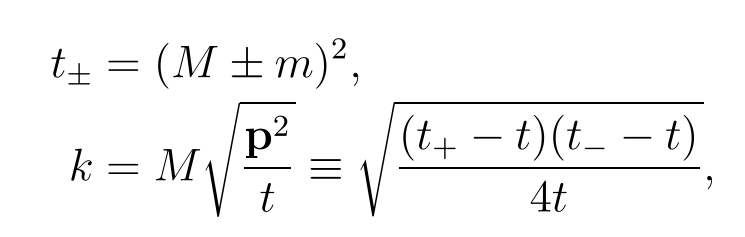

Although in [9705252] $t=q^2$ of the dilepton system, from the introduction of the subtraction point in $\chi$, q2 is really "our" Q2. Just a little ambiguity that needs some caution when at some point they use Q2=-q2

Dictionary: their $\to$ our

$t\to s=q^2$ even if initially also their $q^2$ but inconsistent (see the next)

$q^2 \to Q^2$

# ONE-BODY CONTRIBUTION

In [7]:
f_Bs_star = 0.213

def chi_1pt_V(Q2, f = f_Bs_star):
    return 1/4. * abs(chi.DC9(chi.MBs_star**2))**2 * chi.MBs_star**2 * f**2 / (chi.MBs_star**2 + Q2)**(chi.n_subtractions_plus_1)

In [9]:
for Q2 in [0, chi.mb**2]:
    for f in [0.2, 0.205, 0.210, 0.215, 0.22]:
        print(f"chi_1pt_V at Q^2={Q2} GeV^2 for f={f}: {chi_1pt_V(Q2, f=f):e}")

chi_1pt_V at Q^2=0 GeV^2 for f=0.2: 4.235093e-06
chi_1pt_V at Q^2=0 GeV^2 for f=0.205: 4.449495e-06
chi_1pt_V at Q^2=0 GeV^2 for f=0.21: 4.669190e-06
chi_1pt_V at Q^2=0 GeV^2 for f=0.215: 4.894179e-06
chi_1pt_V at Q^2=0 GeV^2 for f=0.22: 5.124463e-06
chi_1pt_V at Q^2=17.472399999999997 GeV^2 for f=0.2: 1.042168e-06
chi_1pt_V at Q^2=17.472399999999997 GeV^2 for f=0.205: 1.094928e-06
chi_1pt_V at Q^2=17.472399999999997 GeV^2 for f=0.21: 1.148990e-06
chi_1pt_V at Q^2=17.472399999999997 GeV^2 for f=0.215: 1.204355e-06
chi_1pt_V at Q^2=17.472399999999997 GeV^2 for f=0.22: 1.261023e-06


# plot delta chi integrand

In [7]:
print(4 * chi.MD**2, (chi.MB + chi.MK)**2, (chi.MB - chi.MK)**2)

13.94574336 33.375970513636 22.867198825156006


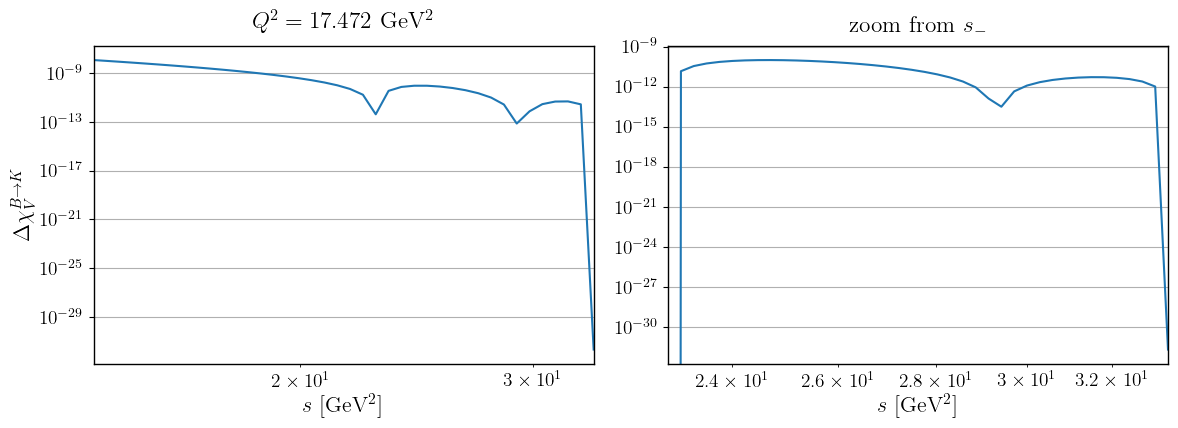

In [4]:
Q2 = chi.mb**2
#Q2 = 0
s_min = 4 * chi.MD**2
s_max = (chi.MB + chi.MK)**2

n_subtractions_plus_1 = 3

nplots = 2

fig, axes = plt.subplots(1, nplots, figsize=(6 * nplots, 4.5))

#0
xmin = s_min
xmax = s_max
#s_vals = np.linspace(xmin, xmax, 10)
s_vals = np.geomspace(xmin, xmax, 40)
f_vals = np.array([chi.to_integrate_delta_V(s, Q2, n_subtractions_plus_1=n_subtractions_plus_1, with_res_factor=True) for s in s_vals])

axes[0].loglog(s_vals, f_vals)
axes[0].set_xlim(xmin, xmax)
axes[0].set_xlabel(R'$s$ [GeV$^2$]')
axes[0].set_title(fR'$Q^2={Q2:<.3f}$ GeV$^2$')
axes[0].grid(True)

#1
xmin = (chi.MB - chi.MK)**2
xmax = s_max
#s_vals = np.linspace(xmin, xmax, 10)
s_vals = np.geomspace(xmin, xmax, 40)
f_vals = np.array([chi.to_integrate_delta_V(s, Q2, n_subtractions_plus_1=n_subtractions_plus_1, with_res_factor=True) for s in s_vals])

axes[1].loglog(s_vals, f_vals)
axes[1].set_xlim(xmin, xmax)
axes[1].set_xlabel(R'$s$ [GeV$^2$]')
axes[1].set_title(fR'zoom from $s_-$')
axes[1].grid(True)

###

axes[0].set_ylabel(R'$\Delta\chi_V^{B\to K}$')
fig.tight_layout()
#fig.savefig("without_res_factor", format="pdf", bbox_inches="tight")
plt.show()

In [2]:
pp = eos.Parameters.Defaults()
oo = eos.Options()
mm = eos.Model.make('SM', pp, oo)


mu = 4.18

# MY SET OF PARAMS
mb = mu
#mc = 1.44423
#alpha_s = mm.alpha_s(mu)
# pp.set('mass::c', mc)
pp.set('mass::b(MSbar)', mb)

# ms = pp['mass::s(2GeV)'].evaluate()

# MB = pp['mass::B_d'].evaluate()
# MK = pp['mass::K_d'].evaluate()
# MD = pp['mass::D^0'].evaluate()

# MBs_star = pp['mass::B_s^*'].evaluate()
# --------------------------

# NICO'S SET OF PARAMS
alpha_s = 0.217
ms = 0.1
mc = 0.29 * mb
pp.set('mass::c', mc)
pp.set('mass::s(2GeV)', ms)

MD = 1.8672
MK = 0.497614
MB = 5.27958
MBs_star = 5.4154
MBs1 = 5.829
MJpsi = 3.070
Mpsi2S = 3.686
pp.set('mass::D^0', MD)
pp.set('mass::K_d', MK)
pp.set('mass::B_d', MB)
pp.set('mass::B_s^*', MBs_star)
pp.set('mass::J/psi', MJpsi)
pp.set('mass::psi(2S)', Mpsi2S)

pp.set('b->s::c1', -0.29063621)
pp.set('b->s::c2', 1.01029623)
# ---------------------------


def wc(mu):
    return mm.wilson_coefficients_b_to_s(mu, 1, False)


wc = wc(mu)

In [10]:
options = {'form-factors':'BSZ2015', 'nonlocal-formfactor':'GRvDV2022order5', 'model':'SM'}
opt = eos.Options(options)

for par, val in zip(chi.bfp.analysis.varied_parameters, chi.bfp.point):
    pp.set(par.name(), float(val))

def H_0_BToK_modsq(s):

    kin = eos.Kinematics({"q2": float(s)})

    re_obs = eos.Observable.make("B->K::Re{H_plus}(q2)", pp, kin, opt).evaluate()
    im_obs = eos.Observable.make("B->K::Im{H_plus}(q2)", pp, kin, opt).evaluate()

    return re_obs**2 + im_obs**2

def H_0_BToK(s):

    kin = eos.Kinematics({"q2": float(s)})

    re_obs = eos.Observable.make("B->K::Re{H_plus}(q2)", pp, kin, opt).evaluate()
    im_obs = eos.Observable.make("B->K::Im{H_plus}(q2)", pp, kin, opt).evaluate()

    return re_obs + 1j * im_obs

def F_0_BToK(s):

    kin = eos.Kinematics({"q2": float(s)})

    re_obs = eos.Observable.make("B->K::F_plus(q2)", pp, kin, opt).evaluate()

    return re_obs 

def FT_0_BToK(s):
    kin = eos.Kinematics({"q2": float(s)})

    re_obs = eos.Observable.make("B->K::F_plus_T(q2)", pp, kin, opt).evaluate()

    return re_obs 

def H_0_modsq_alt(s):
    return 1/(16*np.pi**2)**2 * ( s**2/(4 * MB**4) * abs(chi.DC9(s))**2 * (F_0_BToK(s))**2 + mb**2/MB**2 * abs(chi.DC7(s))**2 * (FT_0_BToK(s))**2 + s*mb/(2*MB**3) * 2*(chi.DC9(s) * chi.DC7(s).conjugate()).real * (F_0_BToK(s) * FT_0_BToK(s)) )

def H_0_estimate(s):
    K_estimate = 100.0
    s_G = 4 * MD**2
    return 1/(16*np.pi**2)**2 * ( s**2/(4 * MB**4) * abs(chi.DC9(s))**2 + mb**2/MB**2 * abs(chi.DC7(s))**2 + s*mb/(2*MB**3) * 2*(chi.DC9(s) * chi.DC7(s).conjugate()).real ) * K_estimate*(s_G/s)**2

In [11]:
print(H_0_BToK_modsq((chi.MB - chi.MK)**2), H_0_BToK((chi.MB - chi.MK)**2), abs(H_0_BToK((chi.MB - chi.MK)**2))**2)
print(H_0_modsq_alt((chi.MB - chi.MK)**2))
print(F_0_BToK((chi.MB - chi.MK)**2), FT_0_BToK((chi.MB - chi.MK)**2))
print(H_0_estimate((chi.MB - chi.MK)**2))

5.67026320831346e+19 (6585888219.276947+3650850373.039647j) 5.670263208313461e+19
9.679681824499199e-06
2.6460878498705056 1.9744928269819624
4.2984660769719553e-05
